[NbViewer Link](https://nbviewer.org/github/su-mana-s/amc-research-sprint/blob/main/eda.ipynb)

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import plotly.express as px


In [71]:
# --- Load datasets ---
data_dir = "./data"

info = pd.read_csv(data_dir + "/amcdata_agreement_info_V2.csv",encoding='cp1252')
vercom = pd.read_csv(data_dir + "/amcdata_vercom_V2.csv")
weapons = pd.read_csv(data_dir + "/amcdata_weapons_facilities_V2.csv")

## Variables - Dictionary

### Agreement_Info

In [72]:

info_cols = ['agreement_id', 'year', 'agreement_profile_title',     
             'laterality', 'adoption_date', 'entry_into_force_date', 
             
             'nr_states_parties_total', 'nr_signatory_states', 
             'nr_states_parties_acceptance', 'nr_states_parties_succession',
             'nr_states_parties_approval', 'nr_states_parties_ratification', 'nr_states_parties_accession', 
             'states_parties_total',
             
             'status', 'state_withdrawal_nr', 'state_withdrawal',
             'weapons_items_topic', 'weapons_items',
             'consultation_mechanism',
             'demonstrated_compliance_mechanism', 'demonstrated_compliance_mechanism_nr',
             'verified_compliance_mechanism', 'verified_compliance_mechanism_nr',
             ]

info_rename = {'agreement_profile_title': "Title",     
             
             
             'nr_states_parties_total': "total_state_parties", 'nr_signatory_states': "signatory_states", 
             'nr_states_parties_acceptance':'sp_acceptance', 'nr_states_parties_succession': 'sp_succession',
             'nr_states_parties_approval': 'sp_approval', 'nr_states_parties_ratification': "sp_ratification", 'nr_states_parties_accession': 'sp_accession', 
             'states_parties_total': 'sp_total',
             
            
             'consultation_mechanism': "consultation_mechanism",
             'demonstrated_compliance_mechanism': "demcom", 'demonstrated_compliance_mechanism_nr': "demcom_nr",
             'verified_compliance_mechanism': "vercom", 'verified_compliance_mechanism_nr': "vercom_nr"
}

info_sub = info[info_cols]

access_map = {
    'verified_compliance_mechanism_area_access': 'Area access',
    'verified_compliance_mechanism_facility_access': 'Facility access',
    'verified_compliance_mechanism_item_access': 'Item access',
    'verified_compliance_mechanism_item_section_access': 'Item section access'
}


weapon_map = {
    '0': 'Nuclear ',
    '1': 'Biological ',
    '2': 'Chemical ',
    '3': 'Conventional ',
    '2, 3': 'Chemical & Conv',
    '4': 'General'
}

mech_map = {
    'consultation_mechanism': 'Consultation',
    'demonstrated_compliance_mechanism': 'Demonstrated compliance',
    'verified_compliance_mechanism': 'Verified compliance'
}

trig_map = {
"0.0":'Agreement',
"1.0":'State-party notification',
"2.0":'State-party request',
"7.0":'Circumstance',                   # Map 7.0 instead 0f 3.0 - err in data/key??
"4.0":'Agreement association',
"5.0":'Other'}

lat_map = {
    "1": 'Bilateral agreement',
    "2": 'Multilateral agreement'
}

inspector_map = {
"0": "Party on party",
"1": "Agreement-established association",
"2": "Utilized association",
"3": "Other"

}

cleaning_dict1 = {
    'weapons_items_topic': weapon_map,
    'laterality': lat_map
}

clean_info = info_sub.copy()
for col in cleaning_dict1.keys():
    clean_info[col] = clean_info[col].astype(str).str.strip()

    clean_info = clean_info.replace(cleaning_dict1)
clean_info = clean_info.rename(columns=info_rename)


In [73]:
print("Total number of agreements: ", len(info), "\n")
print("Years:", info.year.min(), "-", info.year.max(), "\n")
print("*"*50)
print("""\nLaterality distribution: \n0.Unilateral statement or declaration\n1.Bilateral agreement, two states party to the agreement\n2.Multilateral agreements, three or more states party to the agreement\n""")
print(info.laterality.value_counts(), "\n")


Total number of agreements:  128 

Years: 1817 - 2021 

**************************************************

Laterality distribution: 
0.Unilateral statement or declaration
1.Bilateral agreement, two states party to the agreement
2.Multilateral agreements, three or more states party to the agreement

laterality
2    74
1    54
Name: count, dtype: int64 



In [74]:
print("""Status: Status of the agreement as of Decemebr 2023
0.In force
1.Formally terminated
2.Formally expired
3.Obsolete
4.Never entered into force
5.Yet to enter into force\n""")

print(info.status.value_counts())
print("*"*50, '\n')

print("""consultation_mechanism, demonstrated_compliance
_mechanism and verified_compliance_mechanism are flags - 1: presence, 0: absence \n""")
print("""demonstrated_compliance
_mechanism_nr, verified_compliance_mechanism_nr = number of said mechanisms established under that agreement\n""")

print("""-`nr_signatory_states` - Number of signatories
- `nr_states_parties_total` - Total state parties
- `nr_states_parties_ratification` - Ratified parties
- `nr_states_parties_accession` - Acceded parties""")


Status: Status of the agreement as of Decemebr 2023
0.In force
1.Formally terminated
2.Formally expired
3.Obsolete
4.Never entered into force
5.Yet to enter into force

status
0    79
2    13
6    12
4     8
1     8
3     6
5     2
Name: count, dtype: int64
************************************************** 

consultation_mechanism, demonstrated_compliance
_mechanism and verified_compliance_mechanism are flags - 1: presence, 0: absence 

demonstrated_compliance
_mechanism_nr, verified_compliance_mechanism_nr = number of said mechanisms established under that agreement

-`nr_signatory_states` - Number of signatories
- `nr_states_parties_total` - Total state parties
- `nr_states_parties_ratification` - Ratified parties
- `nr_states_parties_accession` - Acceded parties


In [75]:
print("""State Withdrawal: States having formally withdrawn from an agreement in
force as of December 2023 (date of formal withdrawal in
parenthisis) \n\n Read: The USA withdrew from 7 treaties in 2002, all bilateral agreements... ()why?\n\n""", info.state_withdrawal.value_counts())
clean_info[clean_info['state_withdrawal_nr'] > 0]

State Withdrawal: States having formally withdrawn from an agreement in
force as of December 2023 (date of formal withdrawal in
parenthisis) 

 Read: The USA withdrew from 7 treaties in 2002, all bilateral agreements... ()why?

 state_withdrawal
The United States(2002-06-13)                                        7
Japan(1934-12-29)                                                    1
People's Democratic Republic of Korea(2003-01-11)                    1
Saudi Arabia(2024-01-05)                                             1
The United States(2019-08-02)                                        1
The Russian Federation(2023-11-07)                                   1
The Russian Federation(2021-12-18), The United States(2020-11-22)    1
The Russian Federation(2023-11-03)                                   1
Niger(2024-01-28), Mali(2024-01-28), Burkina Faso(2024-01-28)        1
The United States(2018-05-08)                                        1
Name: count, dtype: int64


,agreement_id,year,Title,laterality,adoption_date,entry_into_force_date,total_state_parties,signatory_states,sp_acceptance,sp_succession,...,status,state_withdrawal_nr,state_withdrawal,weapons_items_topic,weapons_items,consultation_mechanism,demcom,demcom_nr,vercom,vercom_nr
5,20,1922,Washington Naval Treaty,Multilateral agreement,NaN,1923-08-17,5.0,5.0,0.0,0.0,...,3,1.0,Japan(1934-12-29),Conventional,"Capital ships, Aircraft Carriers, Merchant Shi...",1.0,1.0,3.0,0.0,NaN
24,90,1968,Non-proliferation Treaty (NPT),Multilateral agreement,1968-07-01,1970-03-05,191.0,93.0,0.0,21.0,...,0,1.0,People's Democratic Republic of Korea(2003-01-11),Nuclear,"Nuclear Weapons, Fissionable Material",1.0,0.0,NaN,0.0,NaN
28,140204,1978,S.C.C Agreed Statements to the AMB Treaty,Bilateral agreement,NaN,1978-11-01,2.0,2.0,0.0,0.0,...,1,1.0,The United States(2002-06-13),Nuclear,"Air Defense Components, Air Defense Radars, Ph...",1.0,1.0,1.0,0.0,NaN
29,140205,1985,S.C.C Common Understandings to the AMB Treaty,Bilateral agreement,NaN,1985-06-06,2.0,2.0,0.0,0.0,...,1,1.0,The United States(2002-06-13),Nuclear,ABM Interceptor Missiles,0.0,1.0,1.0,0.0,NaN
33,1402,1972,Treaty on the Limitation of Anti-Ballistic Mis...,Bilateral agreement,NaN,1972-10-03,2.0,2.0,0.0,0.0,...,1,1.0,The United States(2002-06-13),Nuclear,"ABM Interceptor Missiles, ABM Launchers, ABM R...",1.0,0.0,NaN,1.0,1.0
34,140201,1974,Protocol To The Treaty Between The United Stat...,Bilateral agreement,NaN,1976-05-24,2.0,2.0,0.0,0.0,...,1,1.0,The United States(2002-06-13),Nuclear,"ABM Interceptor Missiles, ABM Launchers, ABM R...",0.0,1.0,1.0,0.0,NaN
35,140202,1974,"Protocol on Procedures Governing Replacement, ...",Bilateral agreement,NaN,1974-07-03,2.0,2.0,0.0,0.0,...,1,1.0,The United States(2002-06-13),Nuclear,ABM Interceptor Missiles (Above ground ABM lau...,0.0,1.0,3.0,0.0,NaN
36,140203,1976,Supplementary Protocol on Replacement to the A...,Bilateral agreement,NaN,1976-10-28,2.0,2.0,0.0,0.0,...,1,1.0,The United States(2002-06-13),Nuclear,"ABM Interceptor Missiles, ABM launchers, ABM R...",0.0,1.0,4.0,0.0,NaN
37,140206,1997,Memorandum Of Understanding Relating To The Tr...,Bilateral agreement,NaN,NaN,6.0,5.0,0.0,0.0,...,1,1.0,The United States(2002-06-13),Nuclear,"ABM Interceptor Missiles, ABM Launchers, ABM R...",1.0,1.0,3.0,1.0,2.0
53,200,1984,Moon Agreement,Multilateral agreement,1979-12-05,1984-07-11,18.0,11.0,0.0,0.0,...,0,1.0,Saudi Arabia(2024-01-05),Nuclear,"Objects Carrying Nuclear Weapons, Weapons of M...",1.0,1.0,10.0,0.0,NaN


In [76]:

print("""
Some agreements have the same adoption date. These usually represent multiple protocols following the same agreement. All of the above are multilateral and are in force (status 0). Not all agreements under one treaty (with the same adoption time), come into effect at the same time.

""")
clean_info[clean_info.groupby('adoption_date')['adoption_date'].transform('count') > 1]



Some agreements have the same adoption date. These usually represent multiple protocols following the same agreement. All of the above are multilateral and are in force (status 0). Not all agreements under one treaty (with the same adoption time), come into effect at the same time.




,agreement_id,year,Title,laterality,adoption_date,entry_into_force_date,total_state_parties,signatory_states,sp_acceptance,sp_succession,...,status,state_withdrawal_nr,state_withdrawal,weapons_items_topic,weapons_items,consultation_mechanism,demcom,demcom_nr,vercom,vercom_nr
17,70,1967,Treaty of Tlatelolco,Multilateral agreement,1967-02-14,1967-09-20,33.0,33.0,0.0,0.0,...,0,0.0,NaN,Nuclear,"Nuclear Weapons, Nuclear Materials",1.0,1.0,5.0,1.0,2.0
18,70001,1967,Protocol I to the Treaty of Tlatelolco,Multilateral agreement,1967-02-14,1969-12-11,4.0,4.0,0.0,0.0,...,0,0.0,NaN,Nuclear,Nuclear Weapons,0.0,0.0,NaN,0.0,NaN
19,70002,1967,Protocol II to the Treaty of Tlatelolco,Multilateral agreement,1967-02-14,1969-12-11,5.0,5.0,0.0,0.0,...,0,0.0,NaN,Nuclear,Nuclear Weapons,0.0,0.0,NaN,0.0,NaN
45,190,1981,Convention on Certain Conventional Weapons (CC...,Multilateral agreement,1980-10-10,1983-12-02,126.0,50.0,5.0,8.0,...,0,0.0,NaN,Conventional,NaN,0.0,1.0,1.0,0.0,NaN
46,190001,1981,Protocol I on Non-Detectable Fragments to the CCW,Multilateral agreement,1980-10-10,1983-12-02,0.0,0.0,0.0,0.0,...,0,0.0,NaN,Conventional,Weapons with the Primary Effect to Injure by N...,0.0,0.0,NaN,0.0,NaN
47,190002,1981,"Protocol II on Mines, BoobyTraps and Other Dev...",Multilateral agreement,1980-10-10,1983-12-02,0.0,0.0,0.0,0.0,...,0,0.0,NaN,Conventional,"Mines, Booby Traps, Other Devises, Mines Other...",0.0,0.0,NaN,0.0,NaN
48,190003,1981,Protocol III on Incediary Weapons to the CCW,Multilateral agreement,1980-10-10,1983-12-02,0.0,0.0,0.0,0.0,...,0,0.0,NaN,Conventional,"Incendiary Weapons, Air-Delivered Incendiary W...",0.0,0.0,NaN,0.0,NaN
55,210001,1986,Protocol I to the Treaty of Rarotonga,Multilateral agreement,1986-08-08,1996-09-20,2.0,3.0,0.0,0.0,...,0,0.0,NaN,Nuclear,"Nuclear Explosive Devises, Fissile Material",0.0,0.0,NaN,0.0,NaN
56,210002,1986,Protocol II to the Treaty of Rarotonga,Multilateral agreement,1986-08-08,1988-04-21,4.0,5.0,0.0,0.0,...,0,0.0,NaN,Nuclear,Nuclear Explosive Devises,0.0,0.0,NaN,0.0,NaN
57,210003,1986,Protocol III to the Treaty of Rarotonga,Multilateral agreement,1986-08-08,1988-04-21,4.0,5.0,0.0,0.0,...,0,0.0,NaN,Nuclear,Nuclear Explosive Devises,0.0,0.0,NaN,0.0,NaN


In [77]:
## Other potentially relevant info

'obligations_weapons_specific', 'weapons_items_topic', 'weapons_items_nr', 
'obligations_location_specific', 'obligations_location', 'obligations_domain_specific', 'obligations_domain',
'obligations_facilites', 'obligations_facilities_nr', 'obligations_facilites_specified',

"""The general topic of weapon items regulated by
agreement:
0.Nuclear weapons
1.Biological weapons
2.Chemical weapons
3.Conventional weapons
4.General"""

info.weapons_items_topic.value_counts()

weapons_items_topic
0       66
3       33
4       11
2        4
1        2
2, 3     1
Name: count, dtype: int64

### VerCom

In [78]:
vercom_cols = ['agreement_id', 
               'verified_compliance_mechanism_type',
               'verified_compliance_mechanism_category', 'verified_compliance_mechanism_inspector_type',
               'verified_compliance_mechanism_inspector_type_established_body',
               'verified_compliance_mechanism_inspector_type_utlilized_body',
               'verified_compliance_mechanism_area_access',
               'verified_compliance_mechanism_facility_access',
               'verified_compliance_mechanism_item_access',
               'verified_compliance_mechanism_item_section_access',
               'verified_compliance_mechanism_area',
               'verified_compliance_mechanism_facility',
               'verified_compliance_mechanism_item',
               'verified_compliance_mechanism_item_section',
               'verified_compliance_mechanism_trigger_type',
               'verified_compliance_mechanism_agreement_trigger_cyclical']
vercom_sub = vercom[vercom_cols]   

cleaning_dict2 = {    'verified_compliance_mechanism_trigger_type': trig_map,
'verified_compliance_mechanism_inspector_type': inspector_map
}

clean_vercom = vercom_sub.copy()
for col in cleaning_dict2.keys():
    clean_vercom[col] = clean_vercom[col].astype(str).str.strip()

    clean_vercom = clean_vercom.replace(cleaning_dict2)


In [79]:
print("Total number of rows: ", len(vercom), "\n")


Total number of rows:  99 



#### Types

In [80]:
print("""Type of verified compliance mechanism:
0.initiated compliance
1.Updated compliance
2.Challenged compliance
3.Completed compliance
4.Other
""")
print(vercom.verified_compliance_mechanism_type.value_counts())


Type of verified compliance mechanism:
0.initiated compliance
1.Updated compliance
2.Challenged compliance
3.Completed compliance
4.Other

verified_compliance_mechanism_type
1.0    46
3.0    20
2.0    13
0.0    10
4.0     1
Name: count, dtype: int64


In [81]:
print("""Category: Type of verified compliance mechanism
- Can also be a contributor to level of intrusiveness
0. NTMs
1. Display
2. Remote monitoring
3. In-person exhibition
4. In-person demonstration
5. In-person Inspection
6. In-person monitoring
7. Other
      """)
print(vercom.verified_compliance_mechanism_category.value_counts())

Category: Type of verified compliance mechanism
- Can also be a contributor to level of intrusiveness
0. NTMs
1. Display
2. Remote monitoring
3. In-person exhibition
4. In-person demonstration
5. In-person Inspection
6. In-person monitoring
7. Other
      
verified_compliance_mechanism_category
5    61
3    12
0    10
6     6
7     4
2     3
1     2
4     1
Name: count, dtype: int64


#### Triggers

In [82]:
print("*"*50)
print("""Type of mechanism trigger;
0.Agreement
1.State-party notification
2.State-party request
3.Circumstance
4.Agreement association
5.Other
      """)
print(vercom.verified_compliance_mechanism_trigger_type.value_counts())

print("*"*50)
print("""Type of agreement trigger:
0.One time
1.Oouta
2.Cyclical
3.Continous
      """)
print(vercom.verified_compliance_mechanism_agreement_trigger_type.value_counts())

print("*"*50)
print("Time in between cyclical verified compliance\n",vercom.verified_compliance_mechanism_agreement_trigger_cyclical.value_counts())

print("*"*50)
print("Agreement association triggering the mechanism", vercom.trigger_association.value_counts())

**************************************************
Type of mechanism trigger;
0.Agreement
1.State-party notification
2.State-party request
3.Circumstance
4.Agreement association
5.Other
      
verified_compliance_mechanism_trigger_type
0    41
1    29
2    11
5    11
4     6
7     1
Name: count, dtype: int64
**************************************************
Type of agreement trigger:
0.One time
1.Oouta
2.Cyclical
3.Continous
      
verified_compliance_mechanism_agreement_trigger_type
0.0    24
3.0    19
2.0    13
1.0     7
4.0     1
Name: count, dtype: int64
**************************************************
Time in between cyclical verified compliance
 Series([], Name: count, dtype: int64)
**************************************************
Agreement association triggering the mechanism trigger_association
United Nations Security Council                                 1
The Consultative Committee                                      1
The Commission                                   

#### Access and Intrusiveness

Access Types
      
1. Area access
The territories, areas, or locations accessible to in-person/remote control.
2. Facility access
The facilities/type of facilities accessible to in-person/remote control.
3. Item access
The objects, structures, and information accessible to in-person/remote control.

In [83]:
print("""Area Access, Facility Access, Item Access, Item Section Access: Binaries - 0/1
      """)
print("""Details of access provisions:
      verified_compliance_mechanism_area, 
      verified_compliance_mechanism_facility, 
      verified_compliance_mechanism_item, verified_compliance_mechanism_item_section
      """)

print("*"*50)


print("""More Access Variables:
      Development Access: 0
      Testing Access: 4
      Production Access: 1
      Acquisition Access: 0
      Possession Access: 50
      Stationing Access: 0
      Use Access: 9
      Transfer Access: 0
""")



Area Access, Facility Access, Item Access, Item Section Access: Binaries - 0/1
      
Details of access provisions:
      verified_compliance_mechanism_area, 
      verified_compliance_mechanism_facility, 
      verified_compliance_mechanism_item, verified_compliance_mechanism_item_section
      
**************************************************
More Access Variables:
      Development Access: 0
      Testing Access: 4
      Production Access: 1
      Acquisition Access: 0
      Possession Access: 50
      Stationing Access: 0
      Use Access: 9
      Transfer Access: 0



In [84]:
print("Area Access Depth - Types of Areas\n")
print(vercom.verified_compliance_mechanism_area.value_counts())

Area Access Depth - Types of Areas

verified_compliance_mechanism_area
Facilities within the territory of the other party and basing countries [Article XI.2].                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  7
Inspectors have access to locations of all underground nuclear explosions conducted outside national nuclear test sites for any given explosion of the other party [Protocol. III. 1].                                                

In [85]:
print("Facility Access Depth - Types of Facilities\n")
print(vercom.verified_compliance_mechanism_facility.value_counts())

Facility Access Depth - Types of Facilities

verified_compliance_mechanism_facility
Facilities not specified                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  5
Within specified territory, inspectors have access to the site of the explosion and facilities and structures related to the conduct of the explosion along agreed routes [Protocol. VII. 2].                           

In [86]:
print("Item Access Depth - Types of Items\n")
print(vercom.verified_compliance_mechanism_item.value_counts())

Item Access Depth - Types of Items

verified_compliance_mechanism_item
Items not specified                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              

In [87]:
print("Item Section Access Depth - Types of Item Sections\n")
print(vercom.verified_compliance_mechanism_item_section.value_counts())

Item Section Access Depth - Types of Item Sections

verified_compliance_mechanism_item_section
Sections not specified                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   

#### Inspection

In [88]:

print("""Inspector Type:
      
The type of inspector;
0.Party on party
1.Agreement-established association
2.Utilized association
3.Other
      """)
print(vercom.verified_compliance_mechanism_inspector_type.value_counts())


Inspector Type:

The type of inspector;
0.Party on party
1.Agreement-established association
2.Utilized association
3.Other
      
verified_compliance_mechanism_inspector_type
0    78
1    11
2    10
Name: count, dtype: int64


### Weapons

In [92]:
weapons_cols = ['agreement_id',"item", 'item_type', 'summary_category', 'ban_development', 'restriction_development', 'ban_production', 'restriction_production', 'ban_transfer', 'restriction_transfer', 'ban_possession', 'restriction_possession', 'ban_use', 'restriction_use']
weapons_sub = weapons[weapons_cols]

In [93]:
print("Total number of rows: ", len(vercom), "\n")

Total number of rows:  99 



In [94]:
print(weapons.item.value_counts())


item
Summary Category A (Nuclear Weapons)              30
Nuclear Weapons                                   17
Summary Category B (Conventional Weapons Land)    14
Weapons General                                    9
Summary Category D (Conventional Weapons Air)      8
                                                  ..
Chemical weapons storage facilities                1
Laser                                              1
Personel/equipment of armed forces                 1
Space Launch Vehicles                              1
Combat Aircraft                                    1
Name: count, Length: 240, dtype: int64


In [95]:
print("""Type of item:
0.Weapons & ammunition
1.Facility
2.Materials/components
3.Other
""")
print(weapons.item_type.value_counts())

print("*"*50)

print("""0.The item is not a fictional summary category added by
AMC Data
1.The item is a fictional summary category added by AMC
Data
""")
print(weapons.summary_category.value_counts())



Type of item:
0.Weapons & ammunition
1.Facility
2.Materials/components
3.Other

item_type
1.0    308
0.0     61
2.0     29
3.0     28
4.0      5
Name: count, dtype: int64
**************************************************
0.The item is not a fictional summary category added by
AMC Data
1.The item is a fictional summary category added by AMC
Data

summary_category
0.0    266
1.0     83
Name: count, dtype: int64


#### Bans and Restrictions

1. Bans:
- Development ban - 34
- Testing ban - 45 
- Acquisition Ban - 54
- Deployed possession Ban
- Use Ban
- Disposal Ban

2. Restrictions:
- Development restriction - 46
- Testing restriction
- Production restriction - 84
- Acquisition restriction
- General possession restriction
- Non-deployed possession restriction
- Deployed possession restriction
- Transfer restriction
- Station restriction
- Disposal restriction


## Distributions

In [97]:
info_ver = info_sub.join(vercom_sub.set_index('agreement_id'), on='agreement_id', how='left')
info_weap = info_sub.join(weapons_sub.set_index('agreement_id'), on='agreement_id', how='left')


In [25]:


def dist(var2_cols, var2_map, weapon_map, df, weapon_col, 
                main_title, plt1_title, plt2_title, p1x, p1y, p2x, p2y):
    df['clean'] = df[weapon_col].astype(str).map(weapon_map)


    counts = df.groupby('clean')[var2_cols].sum()

    counts = counts.rename(columns=var2_map)
    print(counts.values.sum())

    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    plt.suptitle(main_title, fontsize=16)

    # --- (1) Counts: Weapon on X ---
    counts.plot(kind='bar', ax=axes[0])
    axes[0].set_title(plt1_title)
    axes[0].set_xlabel(p1x)
    axes[0].set_ylabel(p1y)
    axes[0].tick_params(axis='x', rotation=30)

    # --- (2) Counts: Access on X ---
    counts.T.plot(kind='bar', ax=axes[1])
    axes[1].set_title(plt2_title)
    axes[1].set_xlabel(p2x)
    axes[1].set_ylabel(p2y)
    axes[1].tick_params(axis='x', rotation=30)

    # --- Clean legends (avoid repetition) ---
    for ax in axes.flat:
        ax.legend().set_title("")

    plt.tight_layout()
    plt.savefig(f"plots/{main_title.replace(' ', '_')}.png")
    plt.show()
    


### Weapon Type

In [ ]:
print(info_sub.verified_compliance_mechanism_nr.value_counts())
title = "Verified Compliance Agreements by Weapon Type"

df = info_ver.copy()
df['weapons_items_topic'] = df['weapons_items_topic'].astype(str).map(weapon_map)
df = df.dropna(subset=['weapons_items_topic'])
df = df.fillna(0)

nice_names = {
    'agreement_id' :    'Agreement ID',
    'year': 'year',
    'laterality':'laterality',
    'state_withdrawal': 'state withdrawal',
    'nr_states_parties_ratification': 'nr_states_parties_ratification',
    'verified_compliance_mechanism_area_access': 'Area access',
    'verified_compliance_mechanism_facility_access': 'Facility access',
    'verified_compliance_mechanism_item_access': 'Item access',
    'verified_compliance_mechanism_item_section_access': 'Item section access',
    'consultation_mechanism': 'Consultation Flag',
    'demonstrated_compliance_mechanism_nr': 'DemCom Count',
    'verified_compliance_mechanism_nr': 'VerCom Count',
    'demonstrated_compliance_mechanism': 'DemCom',
    'verified_compliance_mechanism': 'VerCom'
}
df_renamed = df.rename(columns=nice_names)

fig = px.scatter(
    df_renamed,
    x='weapons_items_topic',
    y='VerCom Count',
    title = title,
    hover_data=list(nice_names.values()),
    labels={
        'weapons_items_topic': 'Weapon Category',
        'VerCom Count': 'VerCom Mechanisms'
    }

)
fig.write_html(f"plots/{title.replace(' ', '_')}.html", full_html=True, include_plotlyjs="inline")
fig.write_image(f"plots/{title.replace(' ', '_')}.png")

fig.show()

verified_compliance_mechanism_nr
1.0     15
0.0      7
2.0      7
3.0      4
4.0      3
5.0      2
9.0      1
17.0     1
11.0     1
Name: count, dtype: int64


120.0


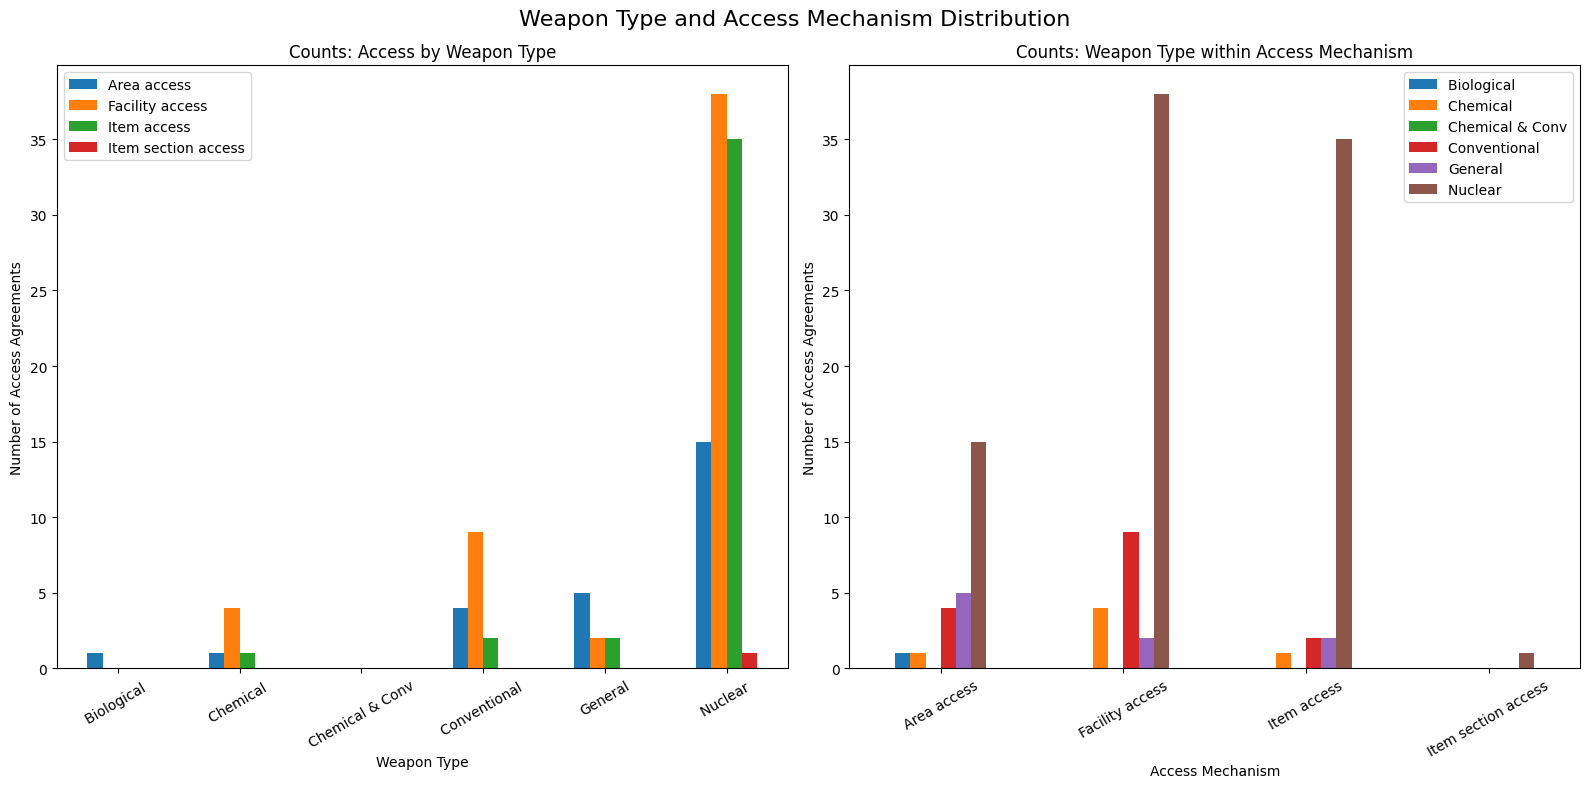

In [28]:
#Total values in the plots might be </> total agreements because not all agreements have any compliance mechanism, and some agreements have multiple mechanisms. 

main_title = "Weapon Type and Access Mechanism Distribution"
plt1_title = "Counts: Access by Weapon Type"
plt2_title = "Counts: Weapon Type within Access Mechanism"
p1x = "Weapon Type"
p1y = "Number of Access Agreements"
p2x = "Access Mechanism"
p2y = "Number of Access Agreements"
access_cols = [
    'verified_compliance_mechanism_area_access',
    'verified_compliance_mechanism_facility_access',
    'verified_compliance_mechanism_item_access',
    'verified_compliance_mechanism_item_section_access'
]


dist(access_cols, access_map, weapon_map, info_ver, 'weapons_items_topic', 
                main_title, plt1_title, plt2_title, p1x, p1y, p2x, p2y)

155.0


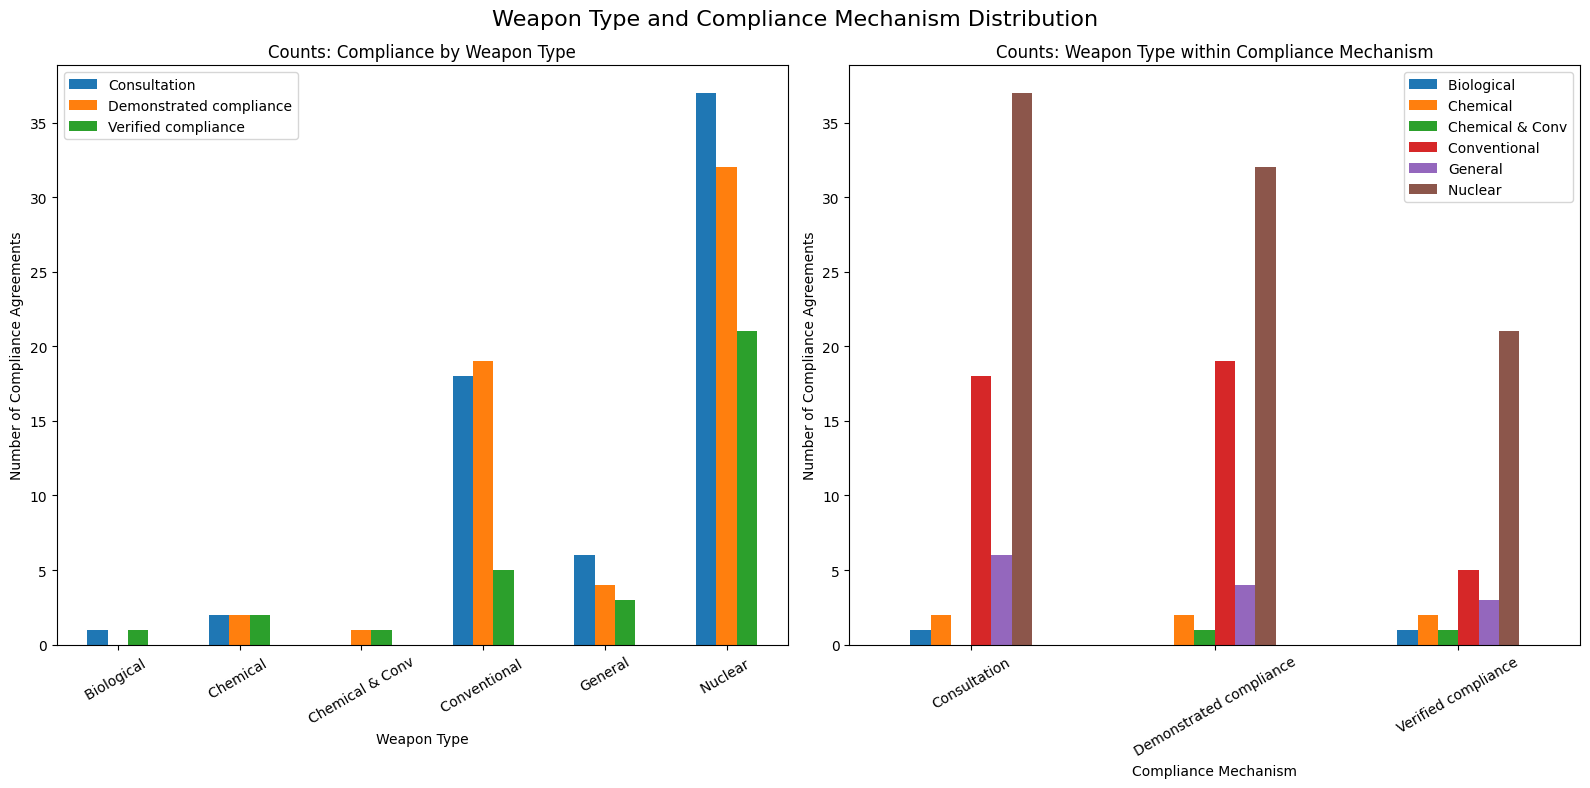

In [29]:
main_title = "Weapon Type and Compliance Mechanism Distribution"
plt1_title = "Counts: Compliance by Weapon Type"
plt2_title = "Counts: Weapon Type within Compliance Mechanism"
p1x = "Weapon Type"
p1y = "Number of Compliance Agreements"
p2x = "Compliance Mechanism"
p2y = "Number of Compliance Agreements"


mech_cols = [
    'consultation_mechanism',
    'demonstrated_compliance_mechanism',
    'verified_compliance_mechanism',
]


dist(mech_cols, mech_map, weapon_map, info_sub, 'weapons_items_topic', 
                main_title, plt1_title, plt2_title, p1x, p1y, p2x, p2y)

### Trigger Type

126.0


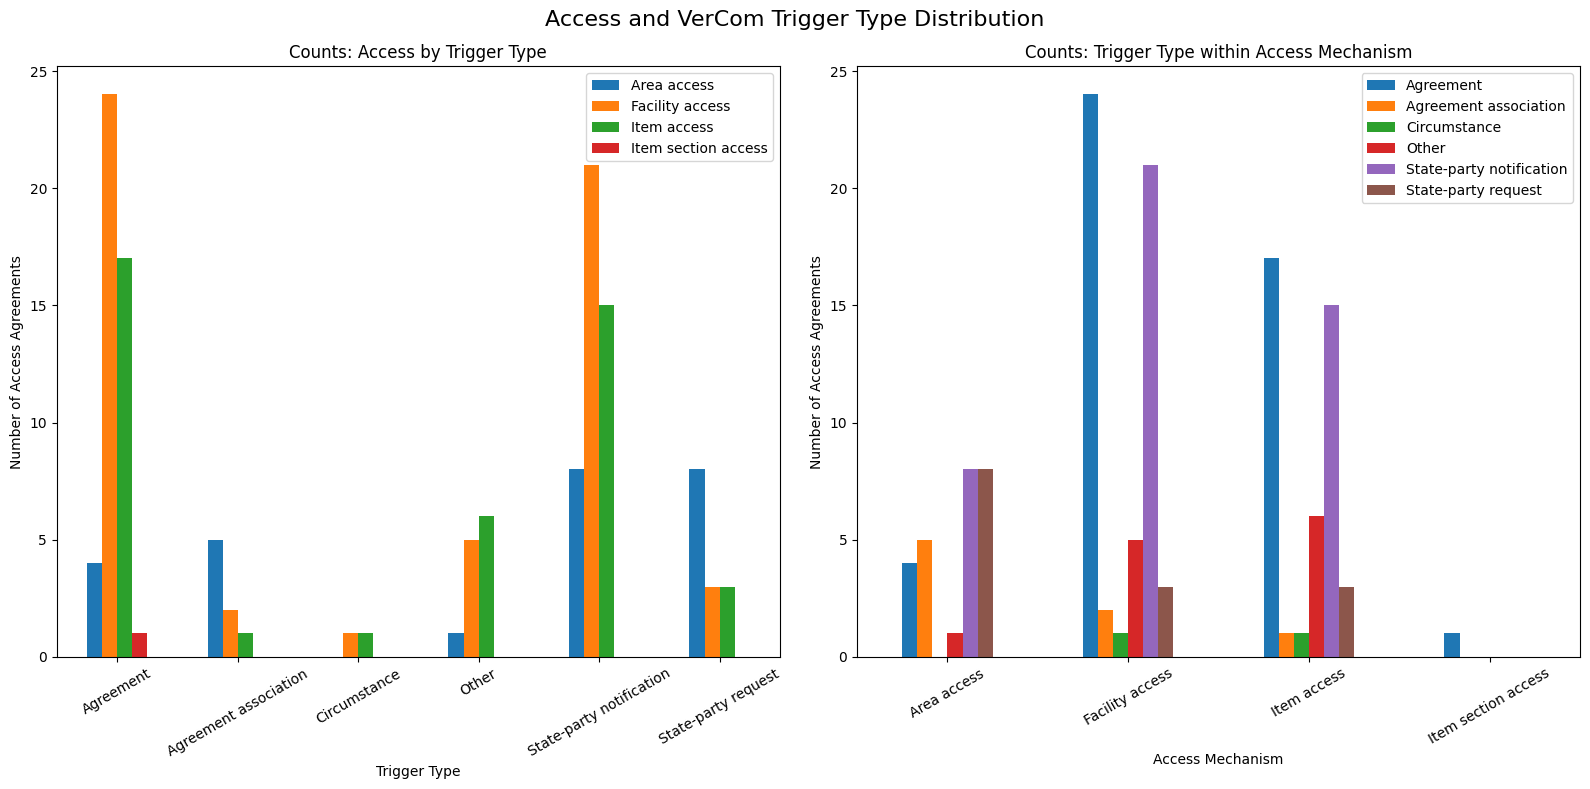

In [30]:
main_title = "Access and VerCom Trigger Type Distribution"

plt1_title = "Counts: Access by Trigger Type"
plt2_title = "Counts: Trigger Type within Access Mechanism"
p1x = "Trigger Type"
p1y = "Number of Access Agreements"
p2x = "Access Mechanism"
p2y = "Number of Access Agreements"


dist(access_cols, access_map, trig_map, info_ver, 'verified_compliance_mechanism_trigger_type', 
                main_title, plt1_title, plt2_title, p1x, p1y, p2x, p2y)

### Laterality

157.0


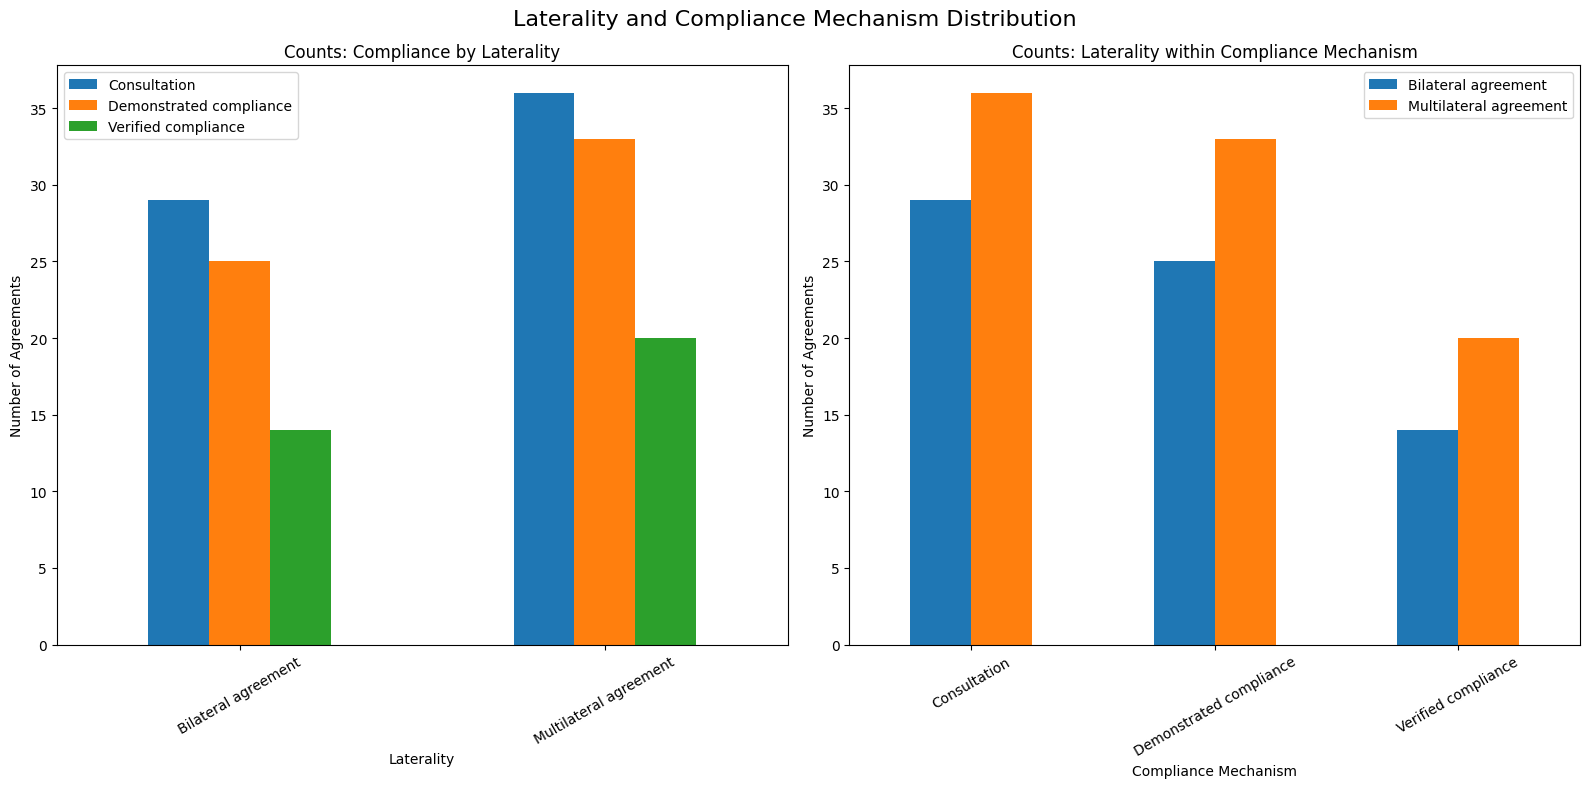

In [31]:
main_title = "Laterality and Compliance Mechanism Distribution"
plt1_title = "Counts: Compliance by Laterality"
plt2_title = "Counts: Laterality within Compliance Mechanism"
p1x = "Laterality"
p1y = "Number of Agreements"
p2x = "Compliance Mechanism"
p2y = "Number of Agreements"

dist(mech_cols, mech_map, lat_map, info_sub, 'laterality', 
                main_title, plt1_title, plt2_title, p1x, p1y, p2x, p2y)

126.0


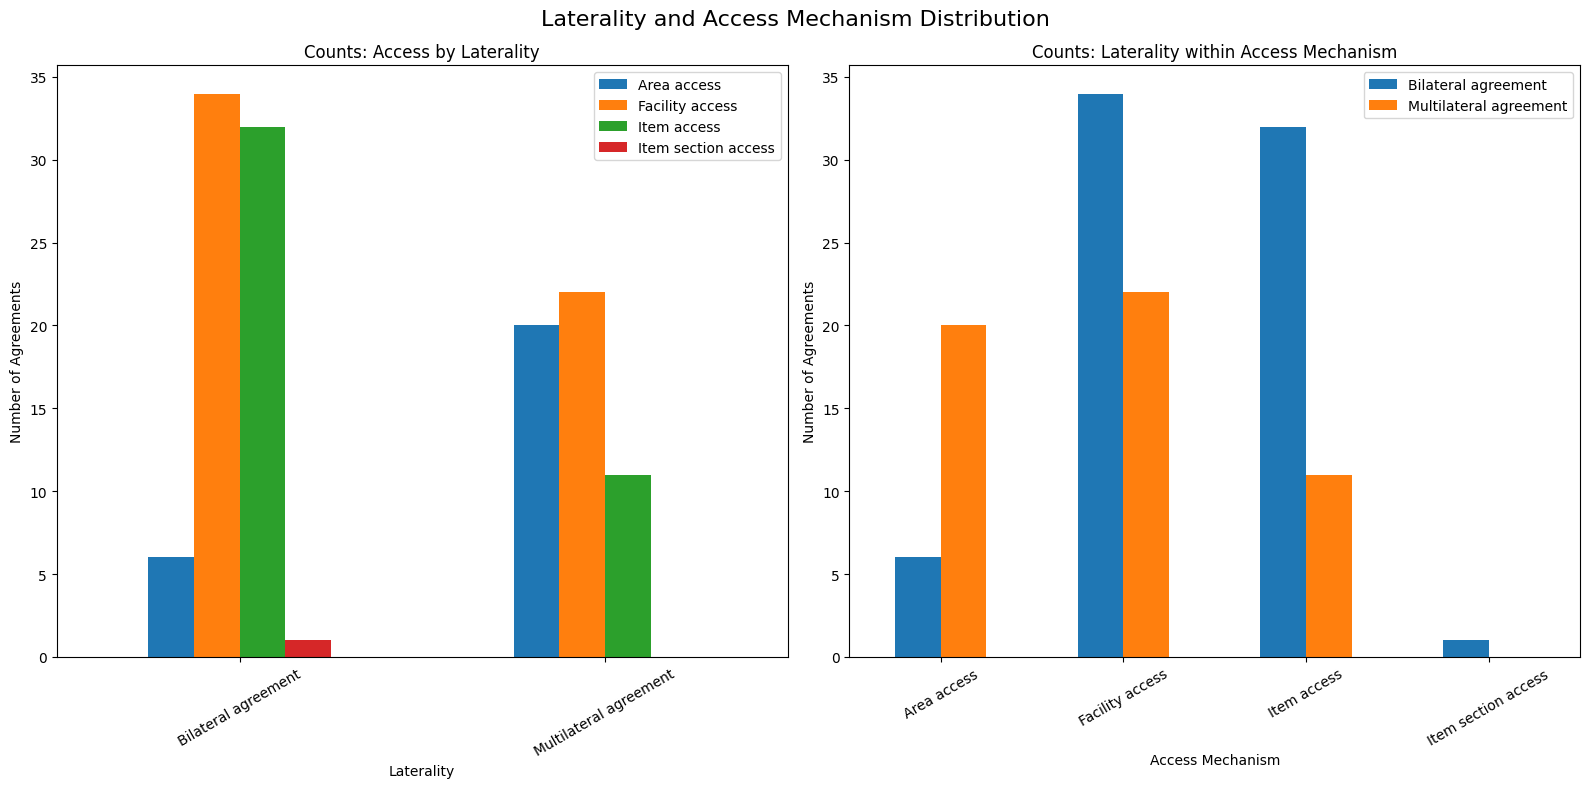

In [32]:
main_title = "Laterality and Access Mechanism Distribution"
plt1_title = "Counts: Access by Laterality"
plt2_title = "Counts: Laterality within Access Mechanism"
p1x = "Laterality"
p1y = "Number of Agreements"
p2x = "Access Mechanism"
p2y = "Number of Agreements"


dist(access_cols, access_map, lat_map, info_ver, 'laterality', 
                main_title, plt1_title, plt2_title, p1x, p1y, p2x, p2y)

### Trends - Time

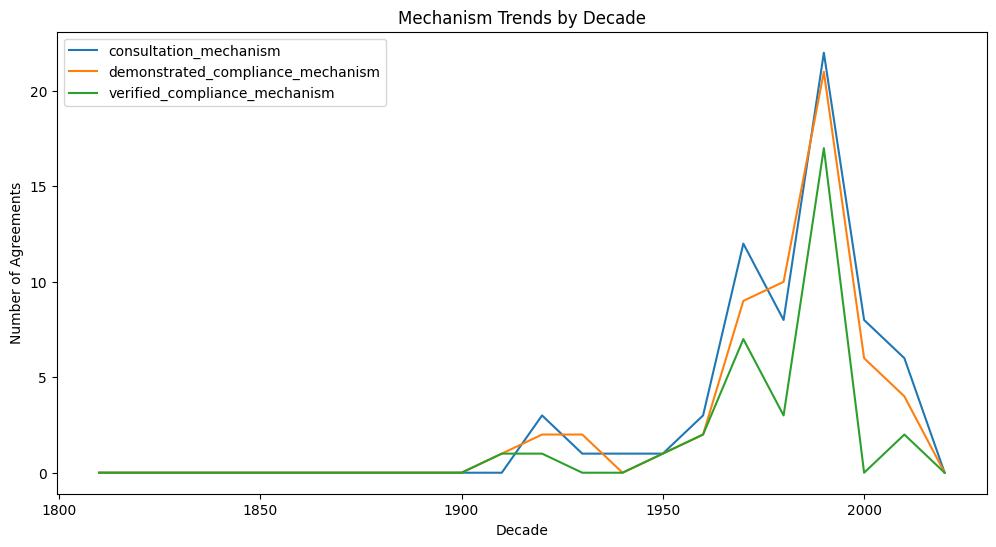

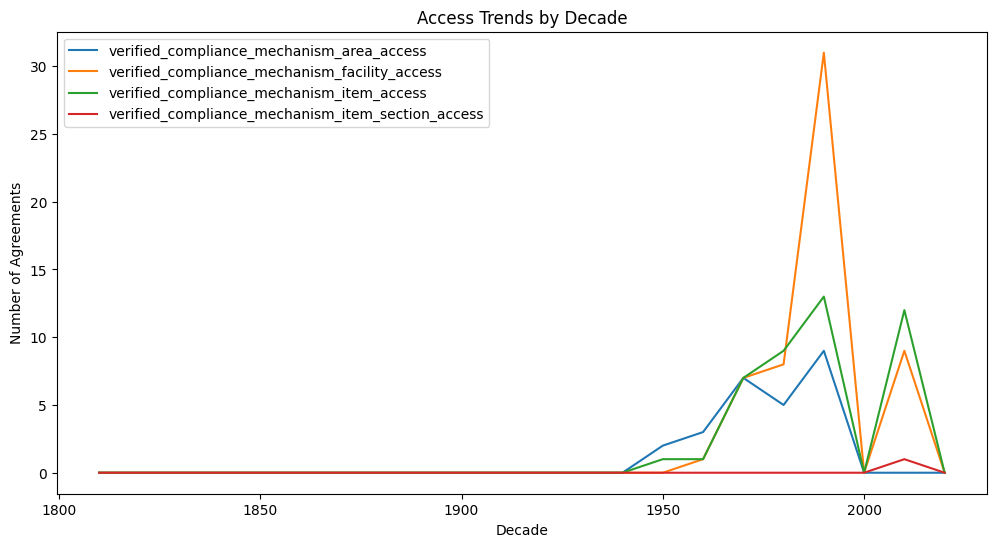

In [33]:
mech_cols = [
    'consultation_mechanism',
    'demonstrated_compliance_mechanism',
    'verified_compliance_mechanism',
]
info_sub['decade'] = (info_sub['year'] // 10) * 10
decade_counts = info_sub.groupby('decade')[mech_cols].sum()
decade_counts.plot(figsize=(12,6))

plt.title("Mechanism Trends by Decade")
plt.xlabel("Decade")
plt.ylabel("Number of Agreements")
plt.savefig("plots/mechanism_trends_by_decade.png")
plt.show()

info_ver['decade'] = (info_ver['year'] // 10) * 10
decade_counts = info_ver.groupby('decade')[access_cols].sum()
decade_counts.plot(figsize=(12,6))

plt.title("Access Trends by Decade")
plt.xlabel("Decade")
plt.ylabel("Number of Agreements")
plt.savefig("plots/access_trends_by_decade.png")
plt.show()


### State Parties
Each point represents an agreement. Hover over the interactive plots to view agreement details



In [34]:
df = info_ver.copy()

df = df.drop_duplicates('agreement_id').copy()
df['decade'] = (df['year'] // 10) * 10
# df['weapons_items_topic'] = df['weapons_items_topic'].fillna("--")
df = df.fillna(0)

nice_names = {
    'agreement_id': 'agreement_id',
    'agreement_profile_title': 'agreement_profile_title',
    'year': 'year',
    'laterality':'laterality',
    'weapons_items_topic': 'weapons_items_topic',
    'state_withdrawal': 'state_withdrawal',
    'nr_states_parties_ratification': 'nr_states_parties_ratification',     
    'verified_compliance_mechanism_area_access': 'Area access',
    'verified_compliance_mechanism_facility_access': 'Facility access',
    'verified_compliance_mechanism_item_access': 'Item access',
    'verified_compliance_mechanism_item_section_access': 'Item section access',
    'consultation_mechanism': 'Consultation Flag',
    'demonstrated_compliance_mechanism_nr': 'DemCom Count',
    'verified_compliance_mechanism_nr': 'VerCom Count',
    'demonstrated_compliance_mechanism': 'DemCom',
    'verified_compliance_mechanism': 'VerCom'
}

df_renamed = df.rename(columns=nice_names)

# hover_cols = ['year', 'agreement_profile_title','laterality', 'agreement_id'] + ['Consultation Flag', 'DemCom Count', 'VerCom Count'] + ['Area access', 'Facility access', 'Item access', 'Item section access']

title = "Total State Parties by Decade"

fig = px.scatter(
    df_renamed,
    x='decade',
    y='nr_states_parties_total',
    hover_data=list(nice_names.values()),
    title = title
)
fig.update_xaxes(title_text='Decade')
fig.update_yaxes(title_text='Total State Parties')

fig.write_html(f"plots/{title.replace(' ', '_')}.html", full_html=True, include_plotlyjs="inline")
fig.write_image(f"plots/{title.replace(' ', '_')}.png")

fig.show()

C:\Users\18055\AppData\Local\Temp\ipykernel_12324\2502751472.py:54: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().set_title("")


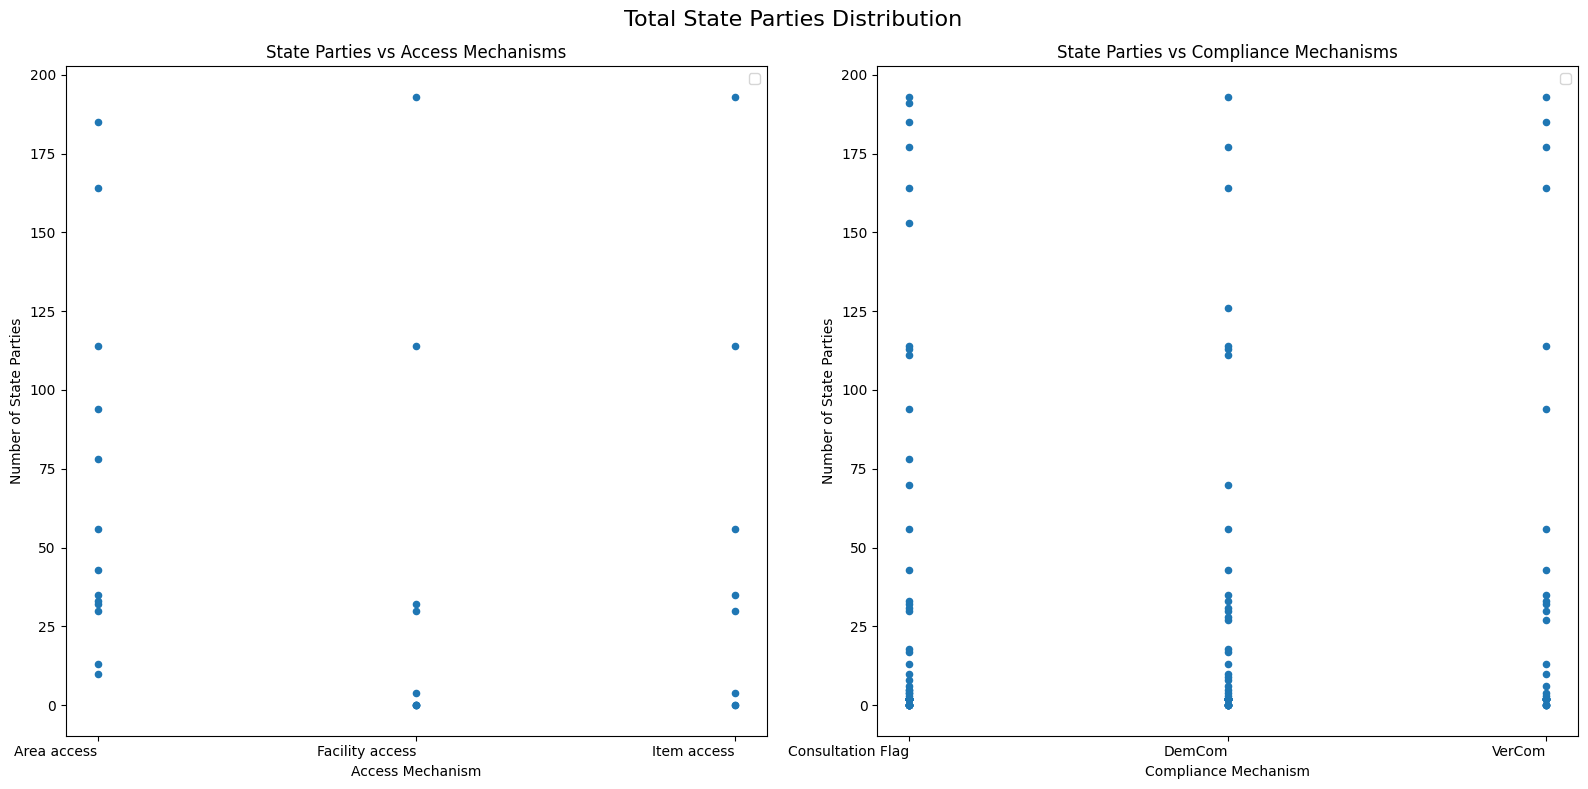

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
title = 'Total State Parties Distribution'
plt.suptitle(title, fontsize=16)

# --- (1)  ---
access_long = df.melt(
    id_vars=['agreement_id', 'nr_states_parties_total'],
    value_vars=access_cols,
    var_name='mechanism',
    value_name='has_mech'
)

# keep only where mechanism exists
access_long = access_long[access_long['has_mech'] == 1]


access_long.plot(kind='scatter', x='mechanism', y='nr_states_parties_total', ax=axes[0])

axes[0].set_title('State Parties vs Access Mechanisms')
axes[0].set_xlabel('Access Mechanism')
axes[0].set_ylabel('Number of State Parties')
axes[0].tick_params(axis='x', rotation=0)

labels0 = [nice_names.get(label.get_text(), label.get_text()) for label in axes[0].get_xticklabels()]
axes[0].set_xticks(axes[0].get_xticks()) # Fixes a Matplotlib warning
axes[0].set_xticklabels(labels0, rotation=0, ha='right')


# # --- (2)  ---

comp_long = df.melt(
    id_vars=['agreement_id', 'nr_states_parties_total'],
    value_vars=mech_cols,
    var_name='mechanism',
    value_name='has_mech'
)

comp_long = comp_long[comp_long['has_mech'] == 1]

comp_long.plot(kind='scatter', x='mechanism', y='nr_states_parties_total', ax=axes[1])

axes[1].set_title('State Parties vs Compliance Mechanisms')
axes[1].set_xlabel('Compliance Mechanism')
axes[1].set_ylabel('Number of State Parties')
axes[1].tick_params(axis='x', rotation=0)

labels1 = [nice_names.get(label.get_text(), label.get_text()) for label in axes[1].get_xticklabels()]
axes[1].set_xticks(axes[1].get_xticks()) # Fixes a Matplotlib warning
axes[1].set_xticklabels(labels1, rotation=0, ha='right')


# --- Clean legends (avoid repetition) ---
for ax in axes.flat:
    ax.legend().set_title("")

plt.tight_layout()
plt.savefig(f"plots/{title.replace(' ', '_')}.png")
plt.show()

In [36]:
df = info_ver.copy()
title = "State Parties by Weapon Type"
df['weapons_items_topic'] = df['weapons_items_topic'].astype(str).map(weapon_map)
df = df.dropna(subset=['weapons_items_topic'])

df = df.fillna(0)

nice_names = {
    'agreement_id' :    'Agreement ID',
    'year': 'year',
    'laterality':'laterality',
    'state_withdrawal': 'state withdrawal',
    'nr_states_parties_ratification': 'nr_states_parties_ratification',
    'verified_compliance_mechanism_area_access': 'Area access',
    'verified_compliance_mechanism_facility_access': 'Facility access',
    'verified_compliance_mechanism_item_access': 'Item access',
    'verified_compliance_mechanism_item_section_access': 'Item section access',
    'consultation_mechanism': 'Consultation Flag',
    'demonstrated_compliance_mechanism_nr': 'DemCom Count',
    'verified_compliance_mechanism_nr': 'VerCom Count',
    'demonstrated_compliance_mechanism': 'DemCom',
    'verified_compliance_mechanism': 'VerCom'
}
df_renamed = df.rename(columns=nice_names)

fig = px.scatter(
    df_renamed,
    x='weapons_items_topic',
    y='nr_states_parties_total',
    title = title,
    hover_data=list(nice_names.values()),
    labels={
        'weapons_items_topic': 'Weapon Category',
        'nr_states_parties_total': 'Total State Parties'
    }

)
fig.write_html(f"plots/{title.replace(' ', '_')}.html", full_html=True, include_plotlyjs="inline")
fig.write_image(f"plots/{title.replace(' ', '_')}.png")


fig.show()

### Inspector Type

126.0


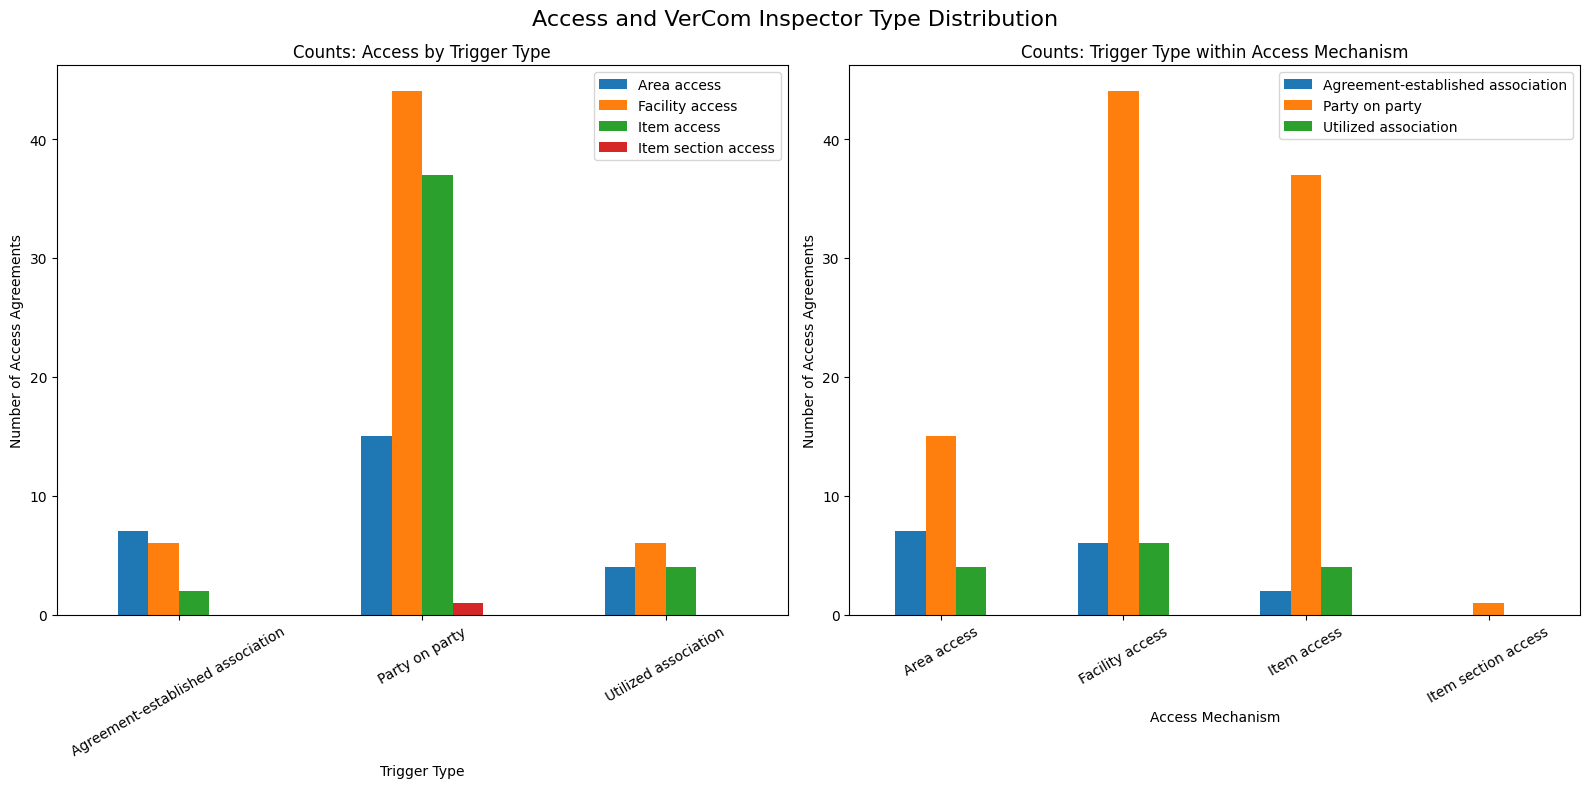

In [37]:
main_title = "Access and VerCom Inspector Type Distribution"

plt1_title = "Counts: Access by Trigger Type"
plt2_title = "Counts: Trigger Type within Access Mechanism"
p1x = "Trigger Type"
p1y = "Number of Access Agreements"
p2x = "Access Mechanism"
p2y = "Number of Access Agreements"


dist(access_cols, access_map, inspector_map, vercom_sub, 'verified_compliance_mechanism_inspector_type', 
                main_title, plt1_title, plt2_title, p1x, p1y, p2x, p2y)



In [38]:
print("Utilised Association\n")
print(vercom.verified_compliance_mechanism_inspector_type_utlilized_body
.value_counts())
clean_vercom[clean_vercom['verified_compliance_mechanism_inspector_type_utlilized_body'].notna()]


Utilised Association

verified_compliance_mechanism_inspector_type_utlilized_body
The IAEA                                                                          8
The Security Council of the United Nation                                         2
The Brazilian-Argentine Agency for Accounting and Control of Nuclear Materials    1
Name: count, dtype: int64


,agreement_id,verified_compliance_mechanism_type,verified_compliance_mechanism_category,verified_compliance_mechanism_inspector_type,verified_compliance_mechanism_inspector_type_established_body,verified_compliance_mechanism_inspector_type_utlilized_body,verified_compliance_mechanism_area_access,verified_compliance_mechanism_facility_access,verified_compliance_mechanism_item_access,verified_compliance_mechanism_item_section_access,verified_compliance_mechanism_area,verified_compliance_mechanism_facility,verified_compliance_mechanism_item,verified_compliance_mechanism_item_section,verified_compliance_mechanism_trigger_type,verified_compliance_mechanism_agreement_trigger_cyclical
2,70,1.0,5,Agreement-established association,The General Secretary(and te technical personn...,The IAEA,1,0,0,0.0,Inspectors have unrestricted access to any are...,NaN,NaN,NaN,1,NaN
3,70,2.0,5,Utilized association,NaN,The IAEA,1,0,0,0.0,Inspectors have access to all places and all i...,NaN,NaN,NaN,2,NaN
7,130,2.0,5,Utilized association,NaN,The Security Council of the United Nation,1,0,0,0.0,Access is granted in accordance with the provi...,NaN,NaN,NaN,2,NaN
20,180,2.0,5,Utilized association,NaN,The Security Council of the United Nation,1,0,0,0.0,Access is granted in accordance with the provi...,NaN,NaN,NaN,4,NaN
80,286,4.0,7,Utilized association,NaN,The Brazilian-Argentine Agency for Accounting ...,0,1,1,0.0,NaN,All nuclear material in all nuclear activities...,All nuclear material in all nuclear activities...,NaN,7,NaN
86,320,1.0,6,Utilized association,NaN,The IAEA,0,1,0,0.0,NaN,"Within specified territory, the designated ins...",NaN,NaN,0,NaN
87,320,1.0,5,Utilized association,NaN,The IAEA,0,1,0,0.0,NaN,"Within specified territory, the designated ins...",NaN,NaN,5,NaN
89,340,2.0,5,Utilized association,NaN,The IAEA,1,0,0,0.0,Inspectors have full and free access to all in...,NaN,NaN,NaN,4,NaN
96,460,1.0,6,Utilized association,NaN,The IAEA,0,1,1,0.0,NaN,The uranium conversion facility (UCF) in Esfah...,"All uranium ore concentrate produced in Iran, ...",NaN,0,NaN
97,460,1.0,6,Utilized association,NaN,The IAEA,0,1,1,0.0,NaN,"All locations and equipment, namely flow-formi...",(i) Information on the initial inventory of al...,NaN,0,NaN


In [39]:
print("Established Association\n")
print(vercom.verified_compliance_mechanism_inspector_type_established_body.value_counts())
clean_vercom[clean_vercom['verified_compliance_mechanism_inspector_type_established_body'].notna()]


Established Association

verified_compliance_mechanism_inspector_type_established_body
Inspectors and inspection assistants designated by the Technical Secretariat                                                          4
Fact Finding Mission                                                                                                                  2
The Organisation                                                                                                                      2
The General Secretary(and te technical personnel)designated by the Council                                                            1
The Brazilian-Argentine Agency for Accounting and Control of Nuclear Materials (hereinafter referred to as the (ABACC) Secretariat    1
The Consultative Committee(Special inspection team)                                                                                   1
Name: count, dtype: int64


,agreement_id,verified_compliance_mechanism_type,verified_compliance_mechanism_category,verified_compliance_mechanism_inspector_type,verified_compliance_mechanism_inspector_type_established_body,verified_compliance_mechanism_inspector_type_utlilized_body,verified_compliance_mechanism_area_access,verified_compliance_mechanism_facility_access,verified_compliance_mechanism_item_access,verified_compliance_mechanism_item_section_access,verified_compliance_mechanism_area,verified_compliance_mechanism_facility,verified_compliance_mechanism_item,verified_compliance_mechanism_item_section,verified_compliance_mechanism_trigger_type,verified_compliance_mechanism_agreement_trigger_cyclical
2,70,1.0,5,Agreement-established association,The General Secretary(and te technical personn...,The IAEA,1,0,0,0.0,Inspectors have unrestricted access to any are...,NaN,NaN,NaN,1,NaN
21,185,1.0,5,Agreement-established association,The Brazilian-Argentine Agency for Accounting ...,NaN,0,1,1,NaN,NaN,Nuclear Facilities,Nuclear Material,NaN,5,NaN
22,210,2.0,5,Agreement-established association,The Consultative Committee(Special inspection ...,NaN,1,0,0,0.0,Inspectors have full and free access to all in...,NaN,NaN,NaN,4,NaN
82,310,0.0,5,Agreement-established association,Inspectors and inspection assistants designate...,NaN,0,1,1,0.0,NaN,Declared facilities,"chemicals, types and number of munitions, devi...",NaN,0,NaN
83,310,2.0,5,Agreement-established association,Inspectors and inspection assistants designate...,NaN,0,1,0,0.0,NaN,Any facility or location in the territory or i...,"On-site/location, insepctors have access to",NaN,2,NaN
84,310,1.0,6,Agreement-established association,Inspectors and inspection assistants designate...,NaN,0,1,0,0.0,NaN,Declared facilities,NaN,NaN,0,NaN
85,310,1.0,5,Agreement-established association,Inspectors and inspection assistants designate...,NaN,1,1,0,0.0,All locations at which chemical weapons specif...,All locations at which chemical weapons specif...,NaN,NaN,5,NaN
88,330,2.0,5,Agreement-established association,Fact Finding Mission,NaN,1,0,0,0.0,Inspectors have unimpeded access to any locati...,NaN,NaN,NaN,2,NaN
93,350,2.0,5,Agreement-established association,The Organisation,NaN,1,1,0,0.0,"The designated inspector, the Organization [Ar...","The designated inspector, the Organization [Ar...",NaN,NaN,4,NaN
94,350,1.0,2,Agreement-established association,The Organisation,NaN,1,0,0,0.0,The international monitoring system (ISM) has ...,NaN,NaN,NaN,0,NaN


### Indexing

In [67]:
df = info_ver.copy()


df['level'] = np.select(
    [
        df['verified_compliance_mechanism_item_section_access'] == 1,
        df['verified_compliance_mechanism_item_access'] == 1,
        df['verified_compliance_mechanism_facility_access'] == 1,
        df['verified_compliance_mechanism_area_access'] == 1
    ],
    [4, 3, 2, 1],
    default=0
)

df['max_level'] = df.groupby('agreement_id')['level'].transform('max')
max_levels = df.groupby('agreement_id', as_index=False)['max_level'].max()
idx = info_sub.copy()
idx = idx.merge(max_levels, on='agreement_id', how='left')

In [108]:
idx[idx['agreement_id'] == 2801]

,agreement_id,year,agreement_profile_title,laterality,adoption_date,entry_into_force_date,nr_states_parties_total,nr_signatory_states,nr_states_parties_acceptance,nr_states_parties_succession,...,weapons_items,consultation_mechanism,demonstrated_compliance_mechanism,demonstrated_compliance_mechanism_nr,verified_compliance_mechanism,verified_compliance_mechanism_nr,clean,decade,max_level,stage_index
70,2801,1991,START I,1,NaN,1994-12-05,2.0,2.0,0.0,NaN,...,"ICBMs, ICBMs of a Retired or Former Type, ICBM...",1.0,1.0,81.0,1.0,17.0,Bilateral agreement,1990,3,2


In [ ]:
## ban development dist differs with each row item in info_weap, even for the same agreement.

In [103]:
# info_weap[info_weap['ban_development'] == 1.0]

In [105]:
agg = info_weap.groupby('agreement_id').agg({
    'ban_development': 'max',
    'restriction_development': 'max',
    'ban_production': 'max',
    'restriction_production': 'max',
    'ban_transfer': 'max',
    'restriction_transfer': 'max'
}).reset_index()

# Pre-capability (development)
agg['pre_cap'] = (
    (agg['ban_development'] == 1) |
    (agg['restriction_development'] == 1)
)

# Post-capability (production / transfer)
agg['post_cap'] = (
    (agg['ban_production'] == 1) |
    (agg['restriction_production'] == 1) |
    (agg['ban_transfer'] == 1) |
    (agg['restriction_transfer'] == 1)
)

import numpy as np

agg['stage_index'] = np.select(
    [
        agg['pre_cap'],                    # highest priority
        (~agg['pre_cap']) & agg['post_cap']
    ],
    [2, 1],
    default=0
)

idx = idx.merge(
    agg[['agreement_id', 'stage_index']],
    on='agreement_id',
    how='left'
)

# stage_map = {
#     0: "no controls",
#     1: "post-capability only",
#     2: "pre-capability included"
# }

# idx['stage'] = idx['stage_index'].map(stage_map)

In [ ]:

intrusiveness_map = {
    1: "Area access",
    2: "Facility access",
    3: "Item access",
    4: "Item-section access"
}

stage_map = {
    0: "No controls",
    1: "Post-capability only",
    2: "Pre-capability included"
}

# Apply mappings
idx['weapon_name'] = idx['weapons_items_topic'].map(weapon_map)
idx['intrusiveness_label'] = idx['max_level'].map(intrusiveness_map)
idx['stage'] = idx['stage_index'].map(stage_map)



In [111]:
idx.groupby("weapons_items_topic")['max_level'].value_counts()

weapons_items_topic  max_level
0                    0            49
                     3            10
                     1             4
                     2             2
                     4             1
1                    1             1
                     0             1
2                    0             3
                     3             1
2, 3                 0             1
3                    0            29
                     1             2
                     3             1
                     2             1
4                    0             8
                     3             2
                     2             1
Name: count, dtype: int64

In [127]:
t = 'Intrusiveness by Weapon Type'
fig1 = px.box(
    idx,
    x='weapon_name',
    y='max_level',
    points='all',
    labels={
        'weapon_name': 'Weapon Type',
        'max_level': 'Intrusiveness'
    },
    title=t
)
fig1.write_html(f"res/{t.replace(' ', '_')}.html", full_html=True, include_plotlyjs="inline")
fig1.write_image(f"res/{t.replace(' ', '_')}.png")

fig1.show()

In [ ]:
counts_lat = (
    idx.groupby(['laterality', 'intrusiveness_label'])
    .size()
    .reset_index(name='count')
)

fig1 = px.bar(
    counts_lat,
    x='laterality',
    y='count',
    color='intrusiveness_label',
    barmode='group',
    labels={
        'laterality': 'Laterality',
        'count': 'Number of Agreements',
        'intrusiveness_label': 'Intrusiveness'
    },
    title='Intrusiveness Distribution by Laterality'
)
fig1.write_html(f"res/{t.replace(' ', '_')}.html", full_html=True, include_plotlyjs="inline")
fig1.write_image(f"res/{t.replace(' ', '_')}.png")

fig1.show()

In [128]:
t = 'Intrusiveness by Weapon Type'
counts_weapon = (
    idx.groupby(['weapon_name', 'intrusiveness_label'])
    .size()
    .reset_index(name='count')
)

fig2 = px.bar(
    counts_weapon,
    x='weapon_name',
    y='count',
    color='intrusiveness_label',
    barmode='group',
    title=t,
    labels = {"count": 'Number of Agreements', 'weapon_name': 'Weapon Type', 'intrusiveness_label': 'Intrusiveness'}
)
fig1.write_html(f"res/{t.replace(' ', '_')}.html", full_html=True, include_plotlyjs="inline")
fig1.write_image(f"res/{t.replace(' ', '_')}.png")

fig2.show()

In [129]:
t = 'Intrusiveness by Capability Stage'
counts_stage = (
    idx.groupby(['stage', 'intrusiveness_label'])
    .size()
    .reset_index(name='count')
)

fig3 = px.bar(
    counts_stage,
    x='stage',
    y='count',
    color='intrusiveness_label',
    barmode='group',
    title=t,
    labels = {"count": 'Number of Agreements', 'stage': 'Capability Stage', 'intrusiveness_label': 'Intrusiveness'}
)
fig1.write_html(f"res/{t.replace(' ', '_')}.html", full_html=True, include_plotlyjs="inline")
fig1.write_image(f"res/{t.replace(' ', '_')}.png")

fig3.show()

In [130]:
heat_counts = idx.groupby(['weapon_name', 'stage']).size().reset_index(name='count')
t = "Agreement Count (Weapon × Stage)"
pivot_counts = heat_counts.pivot(
    index='weapon_name',
    columns='stage',
    values='count'
)

fig4 = px.imshow(
    pivot_counts,
    labels=dict(x="Stage", y="Weapon Type", color="Number of Agreements"),
    title=t
)
fig1.write_html(f"res/{t.replace(' ', '_')}.html", full_html=True, include_plotlyjs="inline")
fig1.write_image(f"res/{t.replace(' ', '_')}.png")

fig4.show()

In [131]:
pivot = idx.pivot_table(
    index='weapon_name',
    columns='stage',
    values='max_level',
    aggfunc='mean'
)
t = "Intrusiveness Heatmap (Weapon × Stage)"
fig4 = px.imshow(
    pivot,
    labels=dict(x="Stage", y="Weapon Type", color="Mean Intrusiveness"),
    title=t
)
fig1.write_html(f"res/{t.replace(' ', '_')}.html", full_html=True, include_plotlyjs="inline")
fig1.write_image(f"res/{t.replace(' ', '_')}.png")

fig4.show()